# 02 - Análisis Exploratorio de la Serie Temporal Financiera

En este cuaderno se realiza un análisis detallado del dataset financiero multivariante, el cual contiene 30 retardos (lags) para 5 activos principales:
- **AAPL** (Apple)
- **GOOGL** (Google)
- **MSFT** (Microsoft)
- **AMZN** (Amazon)
- **JPM** (JPMorgan)

El objetivo es entender las relaciones entre estos activos y cómo sus valores pasados influyen en el `target`.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

## 1. Carga de Datos

In [8]:
csv_path = Path("..") / "data" / "financial_timeseries_dataset.csv"
df = pd.read_csv(csv_path)

print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (3741, 151)


,AAPL_t-0,GOOGL_t-0,MSFT_t-0,AMZN_t-0,JPM_t-0,AAPL_t-1,GOOGL_t-1,MSFT_t-1,AMZN_t-1,JPM_t-1,...,GOOGL_t-28,MSFT_t-28,AMZN_t-28,JPM_t-28,AAPL_t-29,GOOGL_t-29,MSFT_t-29,AMZN_t-29,JPM_t-29,target
0,0.043028,0.240899,-0.295660,1.065966,-0.027733,-0.968555,-0.933868,-1.525425,0.281621,-0.429868,...,-0.918262,0.848036,1.590391,1.168241,-0.293847,-0.552375,-0.372034,-0.074786,0.475469,0
1,-0.968555,-0.933868,-1.525425,0.281621,-0.429868,-0.160780,-0.879317,-1.410288,1.090576,-0.696672,...,-0.552375,-0.372034,-0.074786,0.475469,0.051374,0.689175,0.500887,0.494442,0.771765,0
2,-0.160780,-0.879317,-1.410288,1.090576,-0.696672,0.322046,1.253776,0.732499,-0.172685,0.378839,...,0.689175,0.500887,0.494442,0.771765,-0.410113,-0.276197,-0.302963,-0.572609,-0.477763,0
3,0.322046,1.253776,0.732499,-0.172685,0.378839,-0.560009,-1.228156,-0.126754,-0.224358,-0.842366,...,-0.276197,-0.302963,-0.572609,-0.477763,-0.409464,0.157195,0.180598,1.128484,-0.134140,1
4,-0.560009,-1.228156,-0.126754,-0.224358,-0.842366,-0.706915,-1.162136,-1.077635,-1.384328,-0.459242,...,0.157195,0.180598,1.128484,-0.134140,-1.018243,-0.363337,-0.873900,-1.407218,-0.918039,1


## 2. Análisis de las Acciones en t-0

Primero, observemos el comportamiento de los activos en el tiempo actual (t-0).

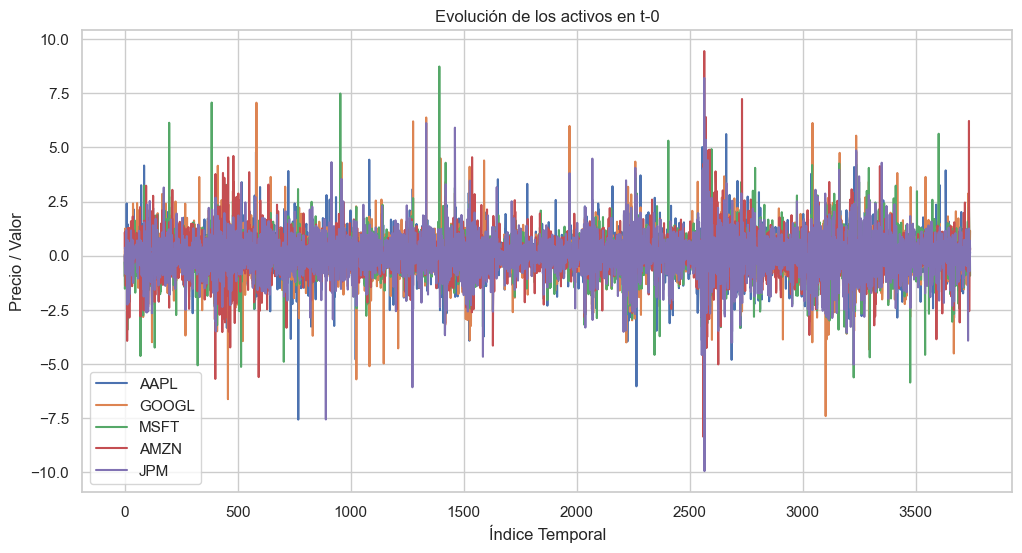

In [9]:
t0_cols = ['AAPL_t-0', 'GOOGL_t-0', 'MSFT_t-0', 'AMZN_t-0', 'JPM_t-0']
df_t0 = df[t0_cols]

plt.figure(figsize=(12, 6))
for col in t0_cols:
    plt.plot(df_t0[col], label=col.split('_')[0])

plt.title("Evolución de los activos en t-0")
plt.xlabel("Índice Temporal")
plt.ylabel("Precio / Valor")
plt.legend()
plt.grid(True)
plt.show()

### Correlación entre activos en t-0

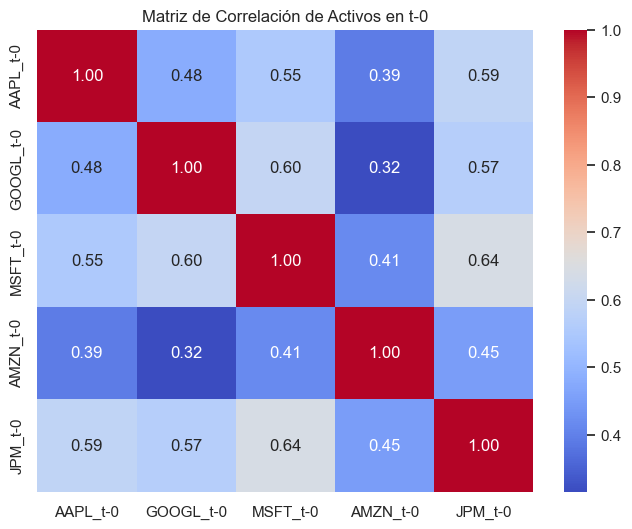

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_t0.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matriz de Correlación de Activos en t-0")
plt.show()

## 3. Análisis de Retardos (Lags)

El dataset contiene retardos desde t-0 hasta t-29. Analicemos cómo se comporta un activo (ej. AAPL) a través de sus retardos.

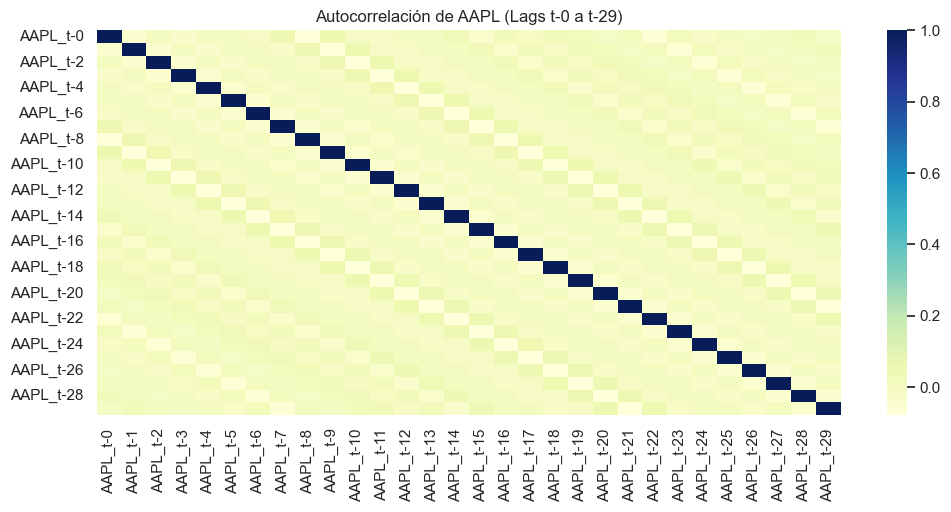

In [11]:
aapl_lags = [f'AAPL_t-{i}' for i in range(30)]
df_aapl_lags = df[aapl_lags]

plt.figure(figsize=(12, 5))
sns.heatmap(df_aapl_lags.corr(), cmap='YlGnBu')
plt.title("Autocorrelación de AAPL (Lags t-0 a t-29)")
plt.show()

## 4. Relación con el Target

El objetivo final es predecir la variable `target`. Veamos qué retardos tienen mayor correlación con ella.

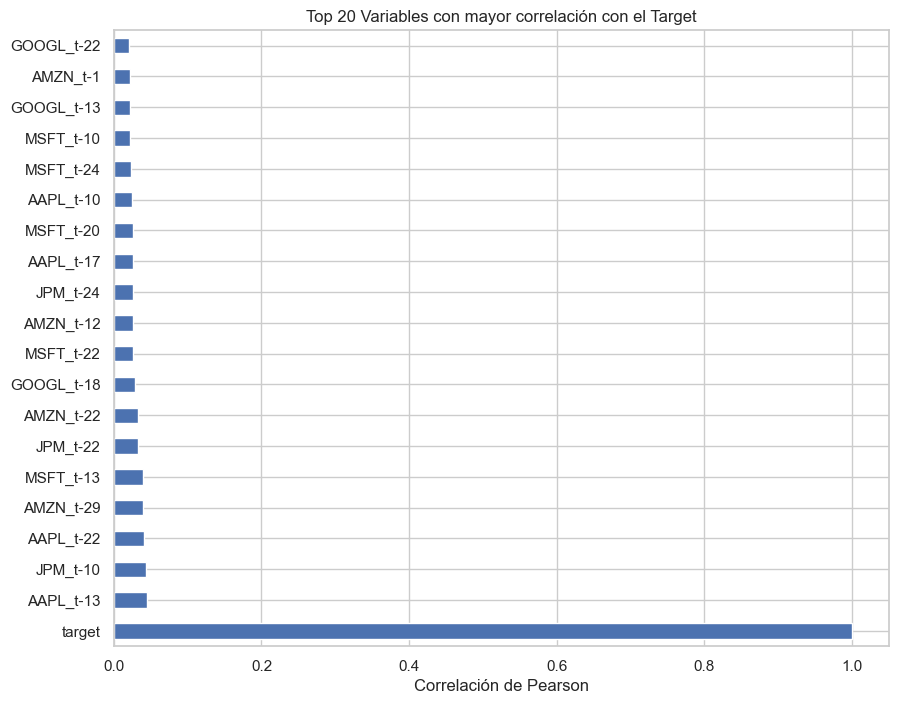

In [12]:
target_corr = df.corr()['target'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
target_corr.head(20).plot(kind='barh')
plt.title("Top 20 Variables con mayor correlación con el Target")
plt.xlabel("Correlación de Pearson")
plt.show()

## 5. Análisis de Estacionariedad (Retornos)

En series financieras, es común trabajar con retornos para lograr estacionariedad.

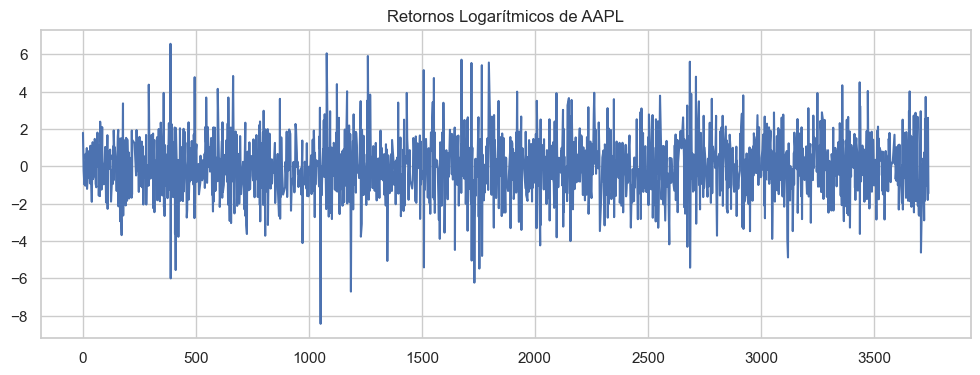

In [13]:
df['AAPL_returns'] = np.log(df['AAPL_t-0'] / df['AAPL_t-1'])

plt.figure(figsize=(12, 4))
plt.plot(df['AAPL_returns'].dropna())
plt.title("Retornos Logarítmicos de AAPL")
plt.grid(True)
plt.show()

## 6. Conclusiones

- El dataset presenta una fuerte correlación entre los activos tecnológicos.
- Los retardos más cercanos (t-0 a t-5) suelen tener mayor peso en la predicción.
- La estructura multivariante permite capturar la influencia cruzada entre diferentes sectores (tecnología y banca).